In [23]:
import xarray as xr
import numpy as np
import cartopy.feature as cfeature
import cartopy.util as u
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
import matplotlib.transforms
from matplotlib import cm
import cmocean
from matplotlib.colors import BoundaryNorm
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import copy
from scipy.io import loadmat

__Area and period of interest__

In [24]:
def merge_files(path1, path2):
    ds1 = xr.open_dataset(path1)
    ds2 = xr.open_dataset(path2)
    ds = xr.merge([ds1, ds2])

    return ds

In [25]:
def area(ds,min_lat, max_lat, min_lon, max_lon):
    ds = ds.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    return ds

In [26]:
def list_sizes(ds):
    sizes = ds.sizes
    print(sizes)
    integer_values_list = [value for value in sizes.values() if isinstance(value, int)]
    return integer_values_list

In [27]:
def area(ds,min_lat, max_lat, min_lon, max_lon):
    ds = ds.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
    return ds

__Calculation of bottom T: new variable__

In [28]:
def calculate_bottom_obs(ds, var_t, var_s, integer_values_list):
    xtbot = xr.DataArray(
        np.empty((len(ds.lat), len(ds.lon)), dtype='float32'),
        dims=("lat", "lon"),
        coords={'lat': ds.lat, 'lon': ds.lon}
    )

    xsbot = xr.DataArray(
        np.empty((len(ds.lat), len(ds.lon)), dtype='float32'),
        dims=("lat", "lon"),
        coords={'lat': ds.lat, 'lon': ds.lon}
    )

    xdbot = xr.DataArray(
        np.empty((len(ds.lat), len(ds.lon)), dtype='float32'),
        dims=("lat", "lon"),
        coords={'lat': ds.lat, 'lon': ds.lon}
    )

    for i in range(integer_values_list[0]):
        for j in range(integer_values_list[2]):
            temperature = ds[var_t].isel(lat=i, lon=j)
            salinity = ds[f'{var_s}'].isel(lat=i, lon=j)
            depth = ds.depth

            nan_indices = np.argwhere(np.isnan(temperature.values))

            if len(nan_indices) == 0:
                xtbot[i, j] = temperature.values[integer_values_list[3]-1].item()
                xsbot[i, j] = salinity.values[integer_values_list[3]-1].item()
                xdbot[i, j] = depth.values[integer_values_list[3]-1].item()
            else:
                first_nan_index = nan_indices[0]
                tbot_index = first_nan_index.item()

                if tbot_index == 0:  # First value is NaN
                    if np.isnan(temperature.values[0]):
                        xtbot[i, j] = temperature.values[0].item()
                        xsbot[i, j] = salinity.values[0].item()
                        xdbot[i, j] = np.nan
                    else:
                        xtbot[i, j] = temperature.values[0].item()
                        xsbot[i, j] = salinity.values[0].item()
                        xdbot[i, j] = depth.values[0].item()
                else:
                    xtbot[i, j] = temperature.values[tbot_index - 1].item()
                    xsbot[i, j] = salinity.values[tbot_index - 1].item()
                    xdbot[i, j] = depth.values[tbot_index - 1].item()

    ds["TBOT"] = xtbot
    ds["SBOT"] = xsbot
    ds["DBOT"] = xdbot
    
    return ds


__Map__

In [43]:
def make_boundary_path(minlon, maxlon, minlat, maxlat, n=50):
    boundary_path = []
    # North (E -> W)
    edge = [np.linspace(minlon, maxlon, n), np.full(n, maxlat)]
    boundary_path += [[i, j] for i, j in zip(*edge)]

    # West (N -> S)
    edge = [np.full(n, maxlon), np.linspace(maxlat, minlat, n)]
    boundary_path += [[i, j] for i, j in zip(*edge)]

    # South (W -> E)
    edge = [np.linspace(maxlon, minlon, n), np.full(n, minlat)]
    boundary_path += [[i, j] for i, j in zip(*edge)]

    # East (S -> N)
    edge = [np.full(n, minlon), np.linspace(minlat, maxlat, n)]
    boundary_path += [[i, j] for i, j in zip(*edge)]

    boundary_path = mpath.Path(boundary_path)

    return boundary_path


def canva(dataset):
    projection = ccrs.Stereographic(central_longitude=75, central_latitude=-65)
    cmap = cmocean.cm.haline
    y = dataset.variables['lat'][:]
    x = dataset.variables['lon'][:]
    X, Y = np.meshgrid(x, y)
    
    norm = colors.Normalize(vmin=dataset.SBOT.min(), vmax=dataset.SBOT.max())

    fig = plt.figure(figsize=(10, 8))

    ax = plt.axes(projection=projection)
    ax.set_xlabel('Longitude', labelpad=0.5)
    ax.set_ylabel('Latitude')
    ax.coastlines()
    ax.add_feature(cfeature.LAND)

    def format_ticks(x, pos):
        return f"{x:.1f}"

    def format_lat_ticks(y, pos):
        return f"{y:.1f}"

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_ticks))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_lat_ticks))

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, rotate_labels=False, x_inline=False, y_inline=False, linewidth=1, color='grey', alpha=0.5, linestyle='-')
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 180+30, 5))
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 90+30, 2.5))

    boundary = make_boundary_path(65, 85, -70, -60)
    ax.set_boundary(boundary, transform=ccrs.PlateCarree())

    ax.set_extent([64.5, 85.5, -71, -59], crs=ccrs.PlateCarree())
    
    mesh = ax.pcolormesh(x, y, dataset.SBOT, cmap=cmap, norm=norm, shading='auto', transform=ccrs.PlateCarree())
    
    cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', fraction=0.1, pad=0.01, shrink=0.5)
    cbar.set_label('Bottom Salinity')

    return fig, ax


__Observation maps__

In [44]:
obs_t = xr.open_dataset('/data/jdelfieu/temperature/woa23_decav_t15_01.nc', decode_times=False)
obs_s = xr.open_dataset('/data/jdelfieu/salinity/woa23_decav_s15_01.nc', decode_times=False)

ds_obs = xr.merge([obs_t, obs_s])

In [45]:
ds_obs = area(ds_obs, -70, -60, 65, 85)

In [46]:
ds_obs = ds_obs.sel(time=403.5)

In [47]:
values_list_obs = list_sizes(ds_obs)

Frozen({'lat': 10, 'nbounds': 2, 'lon': 20, 'depth': 102})


In [48]:
dataset = calculate_bottom_obs(ds_obs, 't_an', 's_an', values_list_obs)

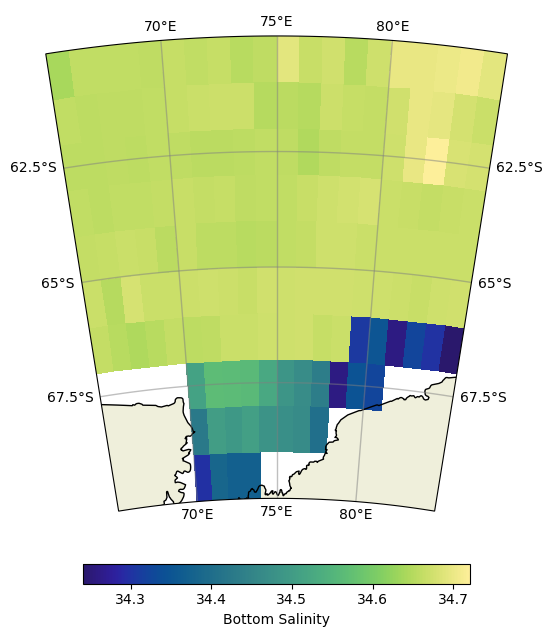

In [49]:
fig, ax = canva(dataset)
plt.show()